# Feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

In [2]:
df = pd.read_csv(
    "../dataset/processed/feature_engineered_house_prices.csv"
)

print(df.shape)

(2997, 12)


In [3]:
features = [
    "BEDS",
    "BATH",
    "PROPERTYSQFT",
    "TYPE",
    "STATE",
    "LOCALITY"
]

X = df[features]
y = df["PRICE"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
categorical_features = [
    "TYPE",
    "STATE",
    "LOCALITY"
]

numerical_features = [
    "BEDS",
    "BATH",
    "PROPERTYSQFT"
]

In [6]:
categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=5
            )
        )
    ]
)

numerical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            categorical_transformer,
            categorical_features
        ),
        (
            "numerical",
            numerical_transformer,
            numerical_features
        )
    ]
)

In [9]:
# train xgboost tuned model again
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.7,
    random_state=42,
    n_jobs=-1,
    objective="reg:squarederror"
)

In [10]:
final_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

In [11]:
final_pipeline.fit(
    X_train,
    y_train
)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('categorical', ...), ('numerical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### extract feature importance

In [12]:
trained_xgb = final_pipeline.named_steps["model"]

In [13]:
fitted_preprocessor = (
    final_pipeline.named_steps["preprocessor"]
)

In [14]:
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

In [15]:
importance = trained_xgb.feature_importances_

In [16]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

feature_importance.head(20)

,Feature,Importance
9,categorical__LOCALITY_Colombo 7,0.160430
43,numerical__PROPERTYSQFT,0.108640
41,numerical__BEDS,0.060037
4,categorical__LOCALITY_Awissawella,0.054345
42,numerical__BATH,0.044843
29,categorical__LOCALITY_Mount Lavinia,0.044686
18,categorical__LOCALITY_Kohuwala,0.036693
36,categorical__LOCALITY_Pitakotte,0.034033
30,categorical__LOCALITY_Nawala,0.033599
31,categorical__LOCALITY_Nugegoda,0.032385


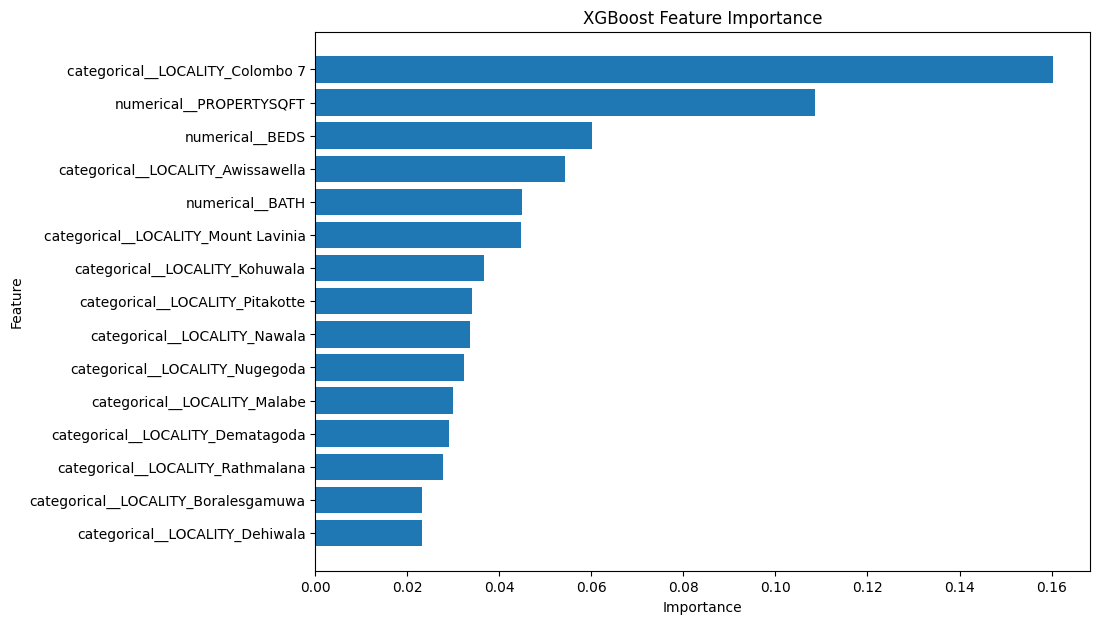

In [ ]:
# plot feature importance

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    "XGBoost Feature Importance"
)

plt.gca().invert_yaxis()

plt.show()

# Shape

In [18]:
import shap

In [19]:
X_test_transformed = (
    fitted_preprocessor.transform(X_test)
)

In [20]:
print(
    X_test_transformed.shape
)

(600, 44)


In [22]:
explainer = shap.TreeExplainer(
    trained_xgb
)

shap_values = explainer(
    X_test_transformed
)

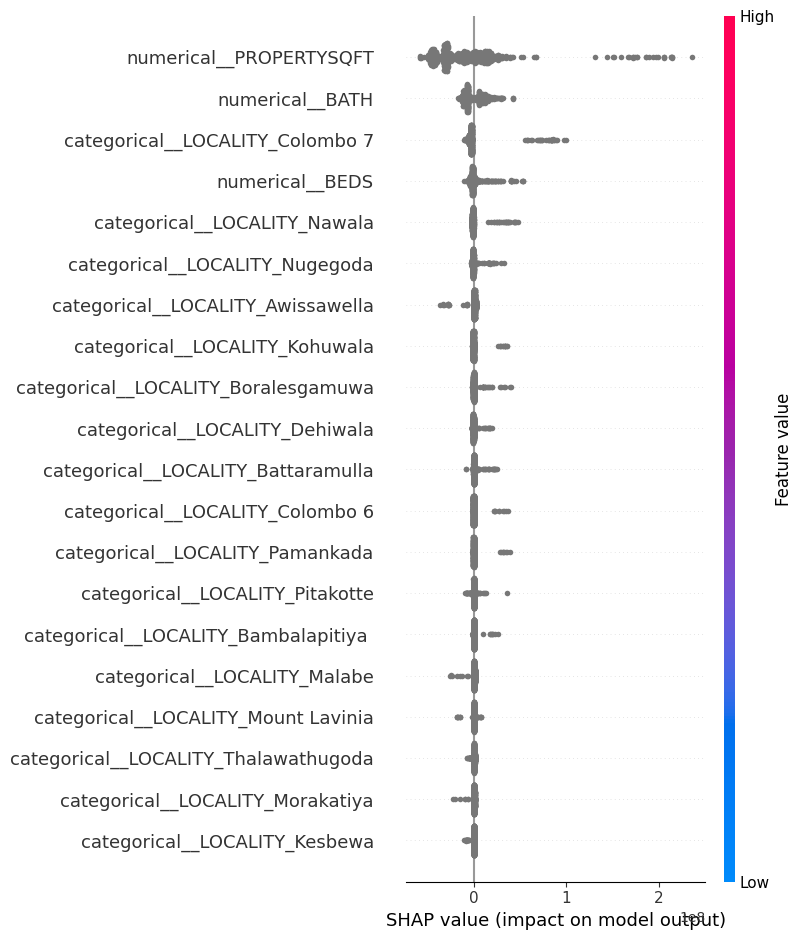

In [23]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

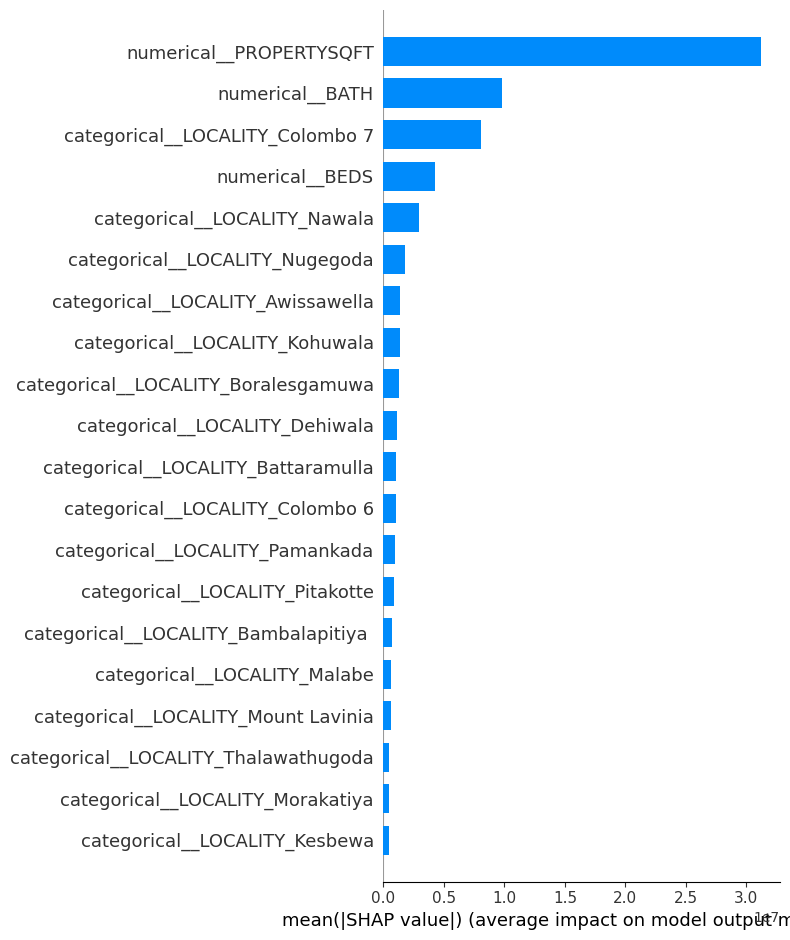

In [24]:
# shap bar plot
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

### explaine one property

In [25]:
sample_index = 0

sample = X_test.iloc[
    [sample_index]
]

sample

,BEDS,BATH,PROPERTYSQFT,TYPE,STATE,LOCALITY
1375,3,4,3512.06,House for sale,Colombo,Thalawathugoda


In [26]:
prediction = final_pipeline.predict(
    sample
)

print(
    f"Predicted Price: "
    f"Rs. {prediction[0]:,.2f}"
)

Predicted Price: Rs. 67,708,608.00


In [27]:
feature_importance.to_csv(
    "../dataset/processed/feature_importance.csv",
    index=False
)